In [154]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# The following is vibe-coded with Gemini; fixed by Kevin Lim and Zihan Guo

# Use float64 for maximum precision with exponential terms
torch.set_default_dtype(torch.float64)

def calculate_J(R1, R2, S0, theta):

    # Slicing the parameters
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1 = torch.cat([nus1, torch.tensor([S0])])
    nus2 = torch.cat([torch.tensor([S0]), nus2])

    # Calculate Unit Base Coefficients (Setting lam1 = 1, lam2 = 1)

    # Left Side
    c_v1_unit = []
    dist0 = nus1[1] - nus1[0]
    c_v1_unit.append((-torch.exp(-dist0/sigs1[0]), torch.exp(dist0/sigs1[0])))

    # recursively calculating c^1
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j+2] - nus1[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * torch.exp(-dist/sigs1[j+1]),
                          0.5 * (P + sigs1[j+1]*S) * torch.exp(dist/sigs1[j+1])))

    # Right Side
    c_v2_unit = [None] * R2
    dist_u = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = ((torch.exp(dist_u/sigs2[-1]), -torch.exp(-dist_u/sigs2[-1])))

    # recursively calculating c^2
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * torch.exp(dist/sigs2[j-1]),
                          0.5 * (P + sigs2[j-1]*S) * torch.exp(-dist/sigs2[j-1]))

    # Unscaled left-side value at S0
    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]

    # Unscaled right-side value at S0
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]

    # Unscaled left-side derivative at S0
    Dk_v1 = (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])

    # Unscaled right-side derivative at S0
    Dk_v2 = (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])

    # Values for lambda1 and lambda2
    lam1 = v2 / (Dk_v1 * v2 - v1 * Dk_v2)
    lam2 = v1 / (Dk_v1 * v2 - v1 * Dk_v2)

    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]

    jumps = []

    # Left Side Jumps
    for j in range(R1 - 1):
        v_left = (1/sigs1[j]**2) * (c_v1[j][0] + c_v1[j][1])
        dist = nus1[j+2] - nus1[j+1]
        v_right = (1/sigs1[j+1]**2) * (c_v1[j+1][0]*torch.exp(dist/sigs1[j+1]) +
                                             c_v1[j+1][1]*torch.exp(-dist/sigs1[j+1]))
        jumps.append(v_right - v_left)

    # Jump at S0
    v1_S0 = (1/sigs1[-1]**2) * (c_v1[-1][0] + c_v1[-1][1])
    v2_S0 = (1/sigs2[0]**2) * (c_v2[0][0] + c_v2[0][1])

    jumps.append(v2_S0 - v1_S0)

    # Right Side Jumps
    for j in range(R2 - 1):
        v_right = (1/sigs2[j+1]**2) * (c_v2[j+1][0] + c_v2[j+1][1])
        dist = nus2[j+1] - nus2[j]
        v_left = (1/sigs2[j]**2) * (c_v2[j][0]*torch.exp(-dist/sigs2[j]) +
                                             c_v2[j][1]*torch.exp(dist/sigs2[j]))
        jumps.append(v_right - v_left)

    j = torch.sum(torch.stack(jumps) ** 2)
    return j, lam1, lam2

In [155]:
def C_K(K, R1, R2, S0, theta):
    # Slicing the parameters
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    nus1 = torch.cat([nus1, torch.tensor([S0])])
    nus2 = torch.cat([torch.tensor([S0]), nus2])

    # Left Side
    c_v1_unit = []
    dist0 = nus1[1] - nus1[0]
    c_v1_unit.append((-torch.exp(-dist0/sigs1[0]), torch.exp(dist0/sigs1[0])))

    # recursively calculating c^1
    for j in range(R1 - 1):
        P = c_v1_unit[j][0] + c_v1_unit[j][1]
        S = (1/sigs1[j]) * (-c_v1_unit[j][0] + c_v1_unit[j][1])
        dist = nus1[j+2] - nus1[j+1]
        c_v1_unit.append((0.5 * (P - sigs1[j+1]*S) * torch.exp(-dist/sigs1[j+1]),
                          0.5 * (P + sigs1[j+1]*S) * torch.exp(dist/sigs1[j+1])))

    # Right Side
    c_v2_unit = [None] * R2
    dist_u = nus2[-1] - nus2[-2]
    c_v2_unit[-1] = ((torch.exp(dist_u/sigs2[-1]), -torch.exp(-dist_u/sigs2[-1])))

    # recursively calculating c^2
    for j in range(R2 - 1, 0, -1):
        P = c_v2_unit[j][0] + c_v2_unit[j][1]
        S = (1/sigs2[j]) * (-c_v2_unit[j][0] + c_v2_unit[j][1])
        dist = nus2[j] - nus2[j-1]
        c_v2_unit[j-1] = (0.5 * (P - sigs2[j-1]*S) * torch.exp(dist/sigs2[j-1]),
                          0.5 * (P + sigs2[j-1]*S) * torch.exp(-dist/sigs2[j-1]))

    # Unscaled left-side value at S0
    v1 = c_v1_unit[-1][0] + c_v1_unit[-1][1]

    # Unscaled right-side value at S0
    v2 = c_v2_unit[0][0] + c_v2_unit[0][1]

    # Unscaled left-side derivative at S0
    Dk_v1 = (1/sigs1[-1]) * (-c_v1_unit[-1][0] + c_v1_unit[-1][1])

    # Unscaled right-side derivative at S0
    Dk_v2 = (1/sigs2[0]) * (-c_v2_unit[0][0] + c_v2_unit[0][1])

    # Values for lambda1 and lambda2
    lam1 = v2 / (Dk_v1 * v2 - v1 * Dk_v2)
    lam2 = v1 / (Dk_v1 * v2 - v1 * Dk_v2)

    c_v1 = [(c1 * lam1, c2 * lam1) for (c1, c2) in c_v1_unit]
    c_v2 = [(c1 * lam2, c2 * lam2) for (c1, c2) in c_v2_unit]


    if K <= S0:
        index = torch.searchsorted(nus1, K, side = 'left') - 1
        dist = nus1[index + 1] - K
        return (c_v1[index][0] * torch.exp(dist/sigs1[index])  + c_v1[index][1] * torch.exp(-dist/sigs1[index])).item() + S0 - K
    else:
        index = torch.searchsorted(nus2, K, side = 'left') - 1
        dist = K - nus2[index]
        return (c_v2[index][0] * torch.exp(-dist/sigs2[index])  + c_v2[index][1] * torch.exp(dist/sigs2[index])).item()


In [156]:
def check_constraints(R1, R2, S0, theta, bid_ask):
    """
    Checks if theta satisfies physical constraints:
    1. nus1 and nus2 are strictly increasing.
    2. sigs1 and sigs2 are strictly positive.
    Returns (is_valid, message)
    """
    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    # Check 1: Strictly increasing knots
    # Note: We must also check the boundaries relative to S0
    increasing_nus1 = torch.all(torch.diff(nus1) > 0) and (nus1[-1] < S0)
    increasing_nus2 = torch.all(torch.diff(nus2) > 0) and (nus2[0] > S0)

    # Check 2: Strictly positive sigmas
    positive_sigs1 = torch.all(sigs1 > 0)
    positive_sigs2 = torch.all(sigs2 > 0)

    bid_ask_check = all([(C_K(ba_range[0], R1, R2, S0, theta) >= ba_range[1] and C_K(ba_range[0], R1, R2, S0, theta) <= ba_range[2]) for ba_range in bid_ask])

    is_valid = increasing_nus1 and increasing_nus2 and positive_sigs1 and positive_sigs2 and bid_ask_check

    return is_valid

def generate_bid_ask(R1, R2, S0, theta, num_contraints = 1, epsilon = 0.1):

    idx = 0
    nus1 = theta[idx : idx + R1]; idx += R1
    sigs1 = theta[idx : idx + R1]; idx += R1
    nus2 = theta[idx : idx + R2]; idx += R2
    sigs2 = theta[idx : idx + R2]; idx += R2

    res = []
    for i in range(num_contraints):
        K1 = (i+1) * (S0 - nus1[0]) / (num_contraints + 1) + nus1[0]
        K2 = (i+1) * (nus2[-1] - S0) / (num_contraints + 1) + S0
        res.append([K1, C_K(K1, R1, R2, S0, theta) - epsilon, C_K(K1, R1, R2, S0, theta) + epsilon])
        res.append([K2, C_K(K2, R1, R2, S0, theta) - epsilon, C_K(K2, R1, R2, S0, theta) + epsilon])

    return res

In [157]:
def bisection_line_search(theta, R1, R2, S0, bid_ask, alpha_max=1e7, max_iter=20):

    curr_alpha = alpha_max

    # Enable gradient tracking
    theta_grad = theta.clone().detach().requires_grad_(True)

    # Forward pass
    loss, _, _ = calculate_J(R1, R2, S0, theta_grad)

    # Backward pass to compute gradients
    loss.backward()
    gradient = theta_grad.grad
    print("Gradient: ", gradient.tolist())

    for i in range(max_iter):
        # Use no_grad for the update and constraint check to avoid tracking these operations
        with torch.no_grad():
            new_theta = (theta - curr_alpha * gradient)

            if check_constraints(R1, R2, S0, new_theta, bid_ask):
                new_loss, _, _ = calculate_J(R1, R2, S0, new_theta)
                if new_loss < loss.item():
                    return new_theta

        curr_alpha /= 2

    return theta

In [158]:
def run_optimization_demo(initial_theta, S0, step_function, bid_ask, num_steps=5, resolution=100, diagnostic_step=1):
    """
    Runs an optimization loop with constraint checking.
    theta = [L, sigma_left, Kbar, sigma_right].
    """
    current_theta = initial_theta.clone().detach()

    for i in range(num_steps):
        L_curr, s_l_curr, Kbar_curr, s_r_curr = current_theta.tolist()

        # 1. Periodic Diagnostic Printing and Plotting
        if i % diagnostic_step == 0:
            J_val, _, _ = calculate_J(1, 1, S0, current_theta)
            print(f"--- Step {i} | J: {J_val.item():.2e} ---")

            # Sample local neighborhood
            s_l_range = np.linspace(1, 120, resolution)
            s_r_range = np.linspace(1, 120, resolution)
            local_X, local_Y = np.meshgrid(s_r_range, s_l_range)
            local_J = np.zeros((resolution, resolution))
            any_valid = False

            for row in range(resolution):
                for col in range(resolution):
                    t_temp = torch.tensor([L_curr, s_l_range[row], Kbar_curr, s_r_range[col]])
                    if check_constraints(1, 1, S0, t_temp, bid_ask):
                        v, _, _ = calculate_J(1, 1, S0, t_temp)
                        local_J[row, col] = v.item()
                        any_valid = True
                    else:
                        local_J[row, col] = np.nan

            if any_valid:
                # Changed to 1x1 subplot layout
                fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))
                cntr = ax1.contourf(local_X, local_Y, np.log10(local_J + 1e-12), levels=30, cmap='viridis')
                fig.colorbar(cntr, ax=ax1, label="log10(J)")
                ax1.set_facecolor('#333333')
                ax1.scatter([s_r_curr], [s_l_curr], color='red', marker='o', s=100, label='Current Point')
                ax1.set_xlabel("sigma right")
                ax1.set_ylabel("sigma left")
                ax1.set_title(f"Valid J Surface at Step {i}")

                plt.tight_layout()
                plt.show()
            else:
                print("Plot skipped: No valid points in neighborhood")

        # 2. Perform and Validate the optimization step
        new_theta = step_function(current_theta, 1, 1, S0, bid_ask)
        current_theta = new_theta

--- Step 0 | J: 5.62e-03 ---


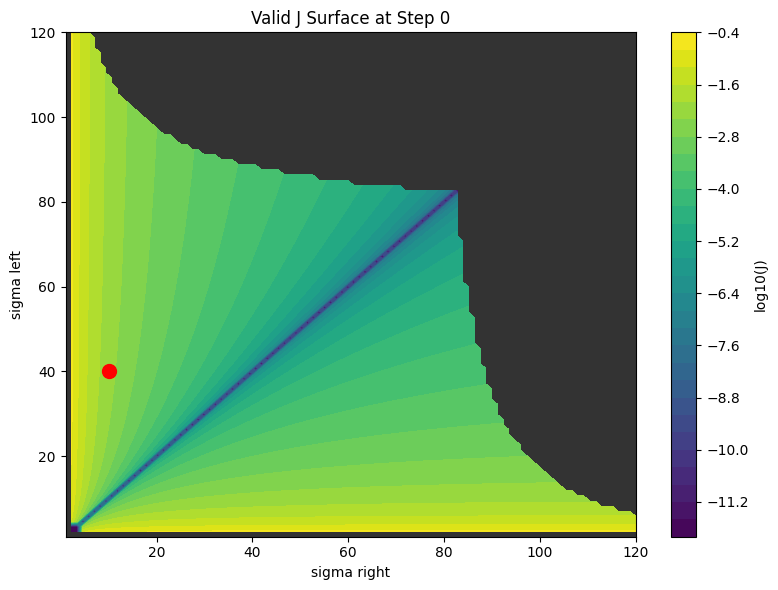

Gradient:  [-4.544150175574624e-20, 9.374999999999882e-05, 3.13653638291292e-19, -0.0015000000000000313]
--- Step 1 | J: 1.67e-04 ---


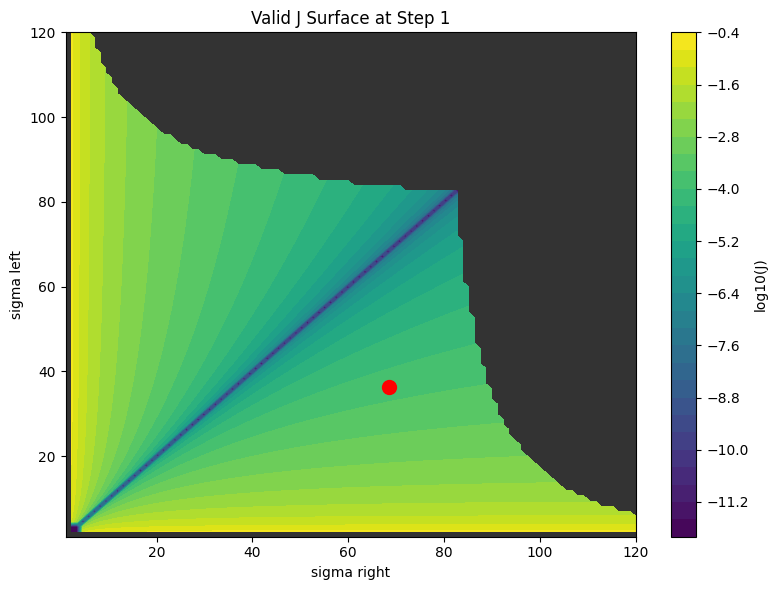

Gradient:  [-3.6408437760009606e-21, -1.9600850955210253e-05, 1.4702556862450112e-18, 5.5007924706708974e-06]
--- Step 2 | J: 4.25e-05 ---


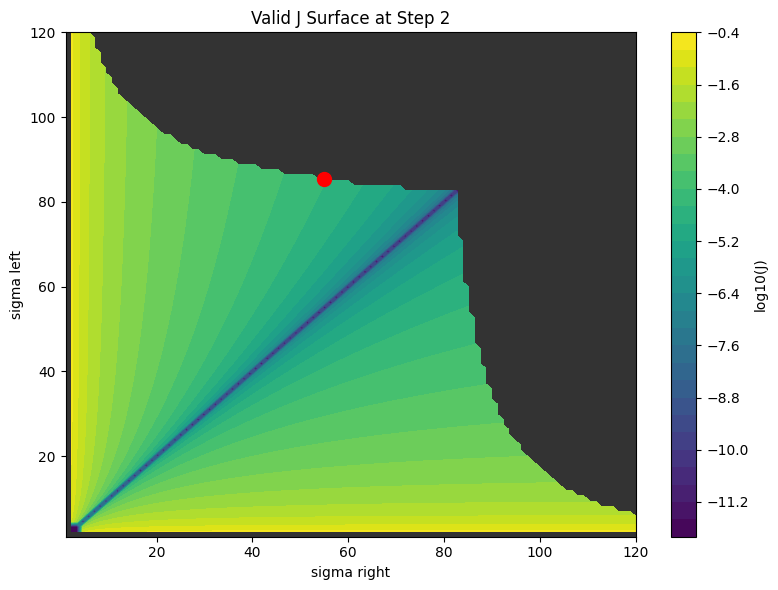

Gradient:  [-1.0337114774060236e-16, 1.7895146559888516e-06, 1.190586006602422e-21, -4.333290580307101e-06]
--- Step 3 | J: 3.92e-10 ---


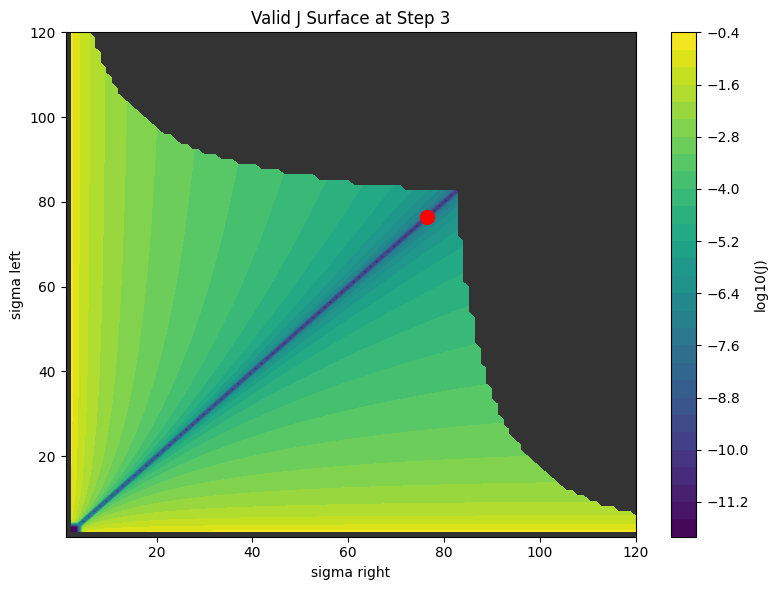

Gradient:  [-8.801014694764904e-23, -6.788798570836542e-09, 9.059208357168661e-23, 6.768267653850636e-09]
--- Step 4 | J: 1.15e-11 ---


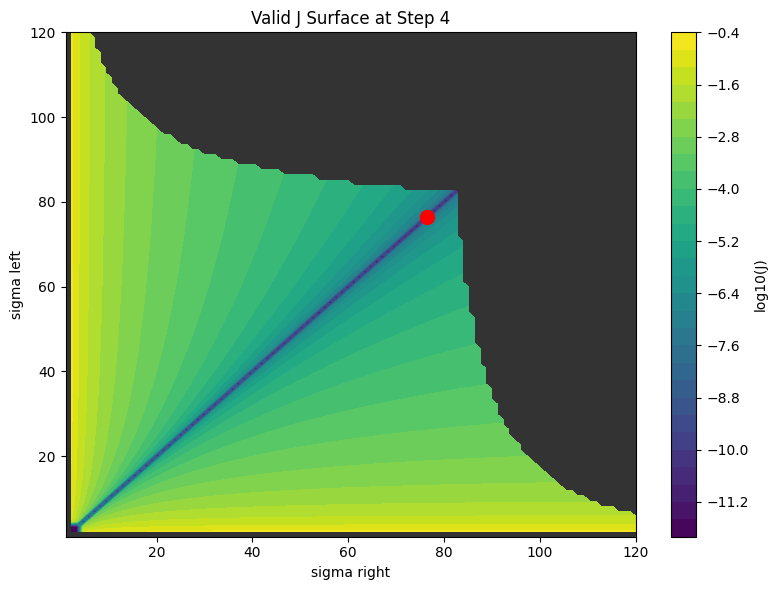

Gradient:  [-2.573568992338667e-24, 1.1585746981541772e-09, 2.570020577408098e-24, -1.1591747832703794e-09]


In [159]:
S0 = 1000
init_theta = torch.tensor([0.0, 40.0, 2000.0, 10.0])
bid_ask_ranges = generate_bid_ask(1, 1, S0, init_theta)
run_optimization_demo(init_theta, S0, bisection_line_search, bid_ask_ranges)